# Belgian residential price evolution by region — last 5 years + 5-year projection

Median sale price for **houses** and **flats (apartments)** per region
(Flanders, Wallonia, Brussels), showing the **last 5 years of history (2020–2025)**
and the **next 5 years projected (2026–2030)**.

**Data** (built by `scripts/build_price_evolution.py`):
- `data/property_prices_historical_by_municipality.csv` — real median sale prices per municipality, 2010–2025 (Statbel, notarial deeds).
- `data/property_prices_projected_by_municipality.csv` — projections per municipality, 2026–2030.

**Read the chart this way:** solid line = real history; dashed line = central projection
(`long_run_base`, +3%/yr); shaded band = scenario range from conservative (+2%/yr) to
optimistic (+4.3%/yr). Projections apply *national* growth rates published by ING/KBC
(to 2027) and a transparent scenario bracket thereafter — they are **not**
municipality-specific forecasts.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")

# Work whether the notebook runs from repo root or from reports/
ROOT = Path.cwd()
if not (ROOT / "data").exists() and (ROOT.parent / "data").exists():
    ROOT = ROOT.parent
DATA, IMAGES = ROOT / "data", ROOT / "images"
IMAGES.mkdir(exist_ok=True)

hist = pd.read_csv(DATA / "property_prices_historical_by_municipality.csv")
proj = pd.read_csv(DATA / "property_prices_projected_by_municipality.csv")

REGIONS       = ["Flanders", "Wallonia", "Brussels"]
REGION_COLOR  = {"Flanders": "#1f77b4", "Wallonia": "#d62728", "Brussels": "#2ca02c"}
TYPES         = {"houses_all": "Houses", "apartments": "Flats"}
HIST_START    = 2020          # last 5 years of history
BASE_YEAR     = 2025          # last actual / projection anchor
SCEN_CENTRAL  = "long_run_base"
SCEN_LO, SCEN_HI = "long_run_conservative", "long_run_optimistic"
print("loaded:", hist.shape, proj.shape)

loaded: (17402, 11) (22705, 17)


In [2]:
def regional_hist(ptype):
    """Transaction-weighted median price per region/year (a region's price is the
    weighted average of its municipal medians, weighted by number of transactions)."""
    d = hist[(hist.property_type == ptype) & (hist.year >= HIST_START)].copy()
    d["wp"] = d.median_price_eur * d.n_transactions
    g = (d.groupby(["region", "year"])
           .agg(wp=("wp", "sum"), w=("n_transactions", "sum"))
           .reset_index())
    g["price"] = g.wp / g.w
    return g.pivot(index="year", columns="region", values="price")


def cum_factor(ptype, scenario):
    """Cumulative growth factor per projection year (national, identical across
    municipalities, so the regional series scales by the same factor)."""
    s = proj[(proj.property_type == ptype) & (proj.scenario == scenario)]
    return (s.groupby("year").cumulative_growth_pct.first() / 100 + 1)

saved /Volumes/nstephane/Dev/AI_Data_Science_training/immo-eliza-teamname-analysis/images/price_evolution_by_region.png


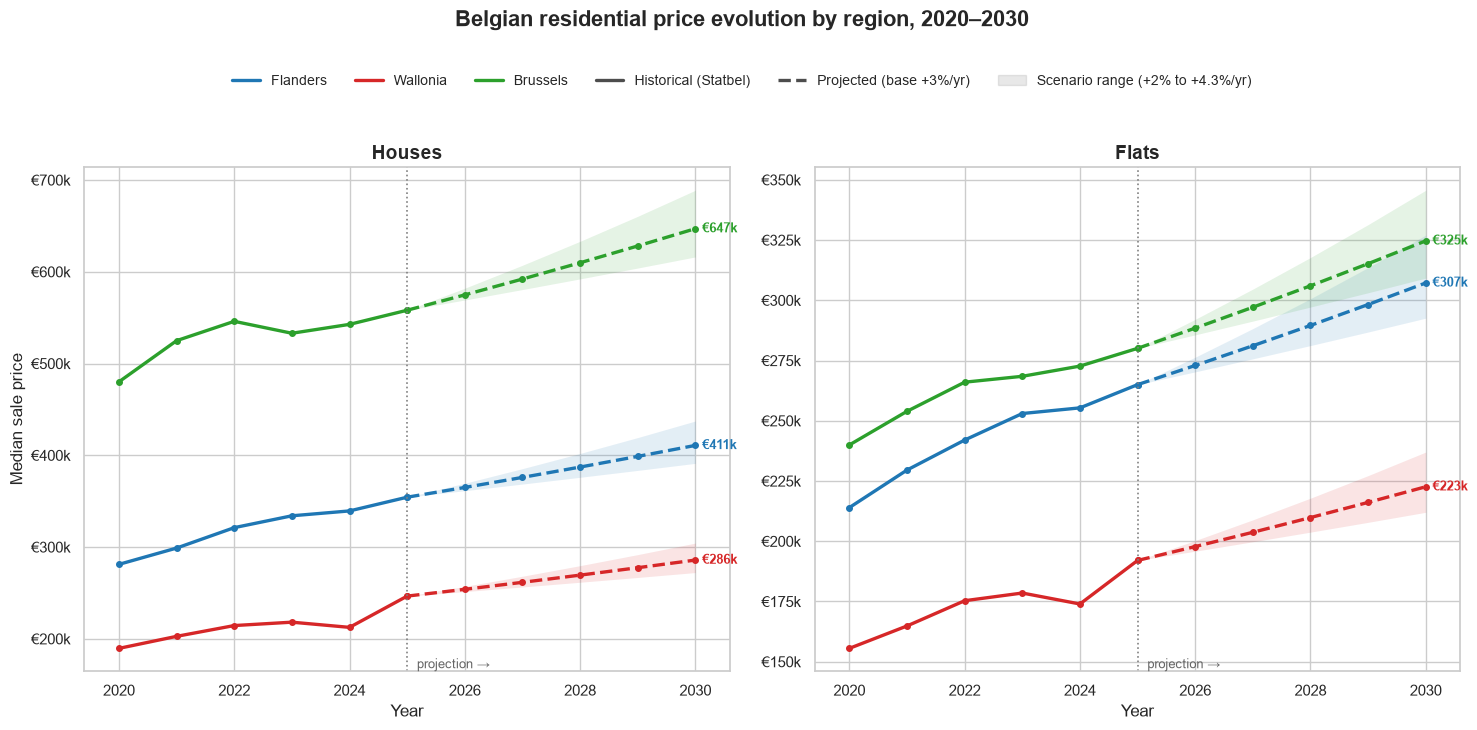

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5), sharey=False)

for ax, (ptype, label) in zip(axes, TYPES.items()):
    h = regional_hist(ptype)
    fac_c = cum_factor(ptype, SCEN_CENTRAL)
    fac_lo = cum_factor(ptype, SCEN_LO)
    fac_hi = cum_factor(ptype, SCEN_HI)
    pyears = list(fac_c.index)                     # [2026..2030]

    for region in REGIONS:
        color = REGION_COLOR[region]
        ax.plot(h.index, h[region], color=color, lw=2.4, marker="o", ms=4)  # history

        base = h.loc[BASE_YEAR, region]
        px = [BASE_YEAR] + pyears                  # anchor projection at last actual
        pc  = [base] + [base * fac_c[y]  for y in pyears]
        plo = [base] + [base * fac_lo[y] for y in pyears]
        phi = [base] + [base * fac_hi[y] for y in pyears]
        ax.plot(px, pc, color=color, lw=2.4, ls="--", marker="o", ms=4)     # projection
        ax.fill_between(px, plo, phi, color=color, alpha=0.12, lw=0)        # scenario band
        ax.annotate(f"€{pc[-1]/1000:,.0f}k", (px[-1], pc[-1]),
                    color=color, fontsize=9, fontweight="bold",
                    xytext=(5, 0), textcoords="offset points", va="center")

    ax.axvline(BASE_YEAR, color="0.5", ls=":", lw=1.2)
    ax.text(BASE_YEAR + 0.1, ax.get_ylim()[0], " projection →", color="0.4",
            fontsize=9, va="bottom")
    ax.set_title(label, fontsize=14, fontweight="bold")
    ax.set_xlabel("Year")
    ax.set_xticks(range(HIST_START, max(pyears) + 1, 2))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"€{v/1000:,.0f}k"))
    ax.margins(x=0.06)

axes[0].set_ylabel("Median sale price")

# one combined legend: region colours + line-style meaning
region_h = [plt.Line2D([], [], color=REGION_COLOR[r], lw=2.4, label=r) for r in REGIONS]
style_h = [
    plt.Line2D([], [], color="0.3", lw=2.4, ls="-",  label="Historical (Statbel)"),
    plt.Line2D([], [], color="0.3", lw=2.4, ls="--", label="Projected (base +3%/yr)"),
    plt.Rectangle((0, 0), 1, 1, color="0.5", alpha=0.18,
                  label="Scenario range (+2% to +4.3%/yr)"),
]
fig.legend(handles=region_h + style_h, loc="upper center", ncol=6,
           frameon=False, bbox_to_anchor=(0.5, 1.04), fontsize=10)
fig.suptitle("Belgian residential price evolution by region, 2020–2030",
             fontsize=16, fontweight="bold", y=1.12)

fig.tight_layout()
out = IMAGES / "price_evolution_by_region.png"
fig.savefig(out, dpi=150, bbox_inches="tight")
print("saved", out)
plt.show()

In [4]:
# Underlying regional numbers + appreciation (handy for the deck)
rows = []
for ptype, label in TYPES.items():
    h = regional_hist(ptype)
    fac_c = cum_factor(ptype, SCEN_CENTRAL)
    end = max(fac_c.index)
    for region in REGIONS:
        p20, p25 = h.loc[HIST_START, region], h.loc[BASE_YEAR, region]
        p30 = p25 * fac_c[end]
        rows.append({
            "type": label, "region": region,
            f"{HIST_START}": round(p20), f"{BASE_YEAR}": round(p25),
            f"{end} (base)": round(p30),
            f"{HIST_START}→{BASE_YEAR} %": round((p25/p20 - 1) * 100, 1),
            f"{BASE_YEAR}→{end} %": round((p30/p25 - 1) * 100, 1),
        })
summary = pd.DataFrame(rows)
summary

,type,region,2020,2025,2030 (base),2020→2025 %,2025→2030 %
0,Houses,Flanders,281157,354339,410785,26.0,15.9
1,Houses,Wallonia,189589,246549,285824,30.0,15.9
2,Houses,Brussels,480095,558097,647002,16.2,15.9
3,Flats,Flanders,213973,265001,307216,23.8,15.9
4,Flats,Wallonia,155542,192031,222621,23.5,15.9
5,Flats,Brussels,239976,280063,324677,16.7,15.9


### How to read it

- **History (solid):** Flanders and Brussels carry the highest price levels; Wallonia
  is structurally cheaper — the gap an investor trades off against higher rental yield.
- **Projection (dashed):** the central path grows ~3%/yr; the shaded band shows the
  conservative-to-optimistic range. Because the projection applies a *national* rate
  uniformly, the regions keep their relative order — only the levels rise.
- The summary table gives the exact 2020→2025 (realised) and 2025→2030 (projected)
  appreciation per region and type.

> Per the team convention, clear notebook outputs before committing
> (`jupyter nbconvert --clear-output --inplace reports/price_evolution.ipynb`).
> The chart is also saved to `images/price_evolution_by_region.png` for the deck.